Cell 1: Title
# DistilBERT Evaluation vs TF-IDF Baseline
Load trained model, evaluate on held-out test set, compare metrics.

In [1]:
# Cell 2: Imports
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import DistilBertForSequenceClassification, DistilBertTokenizerFast
from sklearn.metrics import classification_report, confusion_matrix
from datasets import load_dataset

import sys
sys.path.append('..')
from src.ml.data import preprocess_dataset, load_emotion_dataset, get_label_names

sns.set_style("whitegrid")

/home/khalifa/Repository_Projects/ml-emotion-intelligence-system/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Cell 3: Load model and dataset
model_path = "../models/distilbert-emotion-v1"
print(f'Loading from: {model_path}')
model = DistilBertForSequenceClassification.from_pretrained(model_path, local_files_only=True)
tokenizer = DistilBertTokenizerFast.from_pretrained(model_path, local_files_only=True)

dataset = load_emotion_dataset()
tokenized_dataset = preprocess_dataset(dataset, tokenizer)
label_names = get_label_names(dataset)

print(f"Test samples: {len(tokenized_dataset['test'])}") 
print(f"Labels: {label_names}")

Loading from: ../models/distilbert-emotion-v1


Loading weights: 100%|██████████| 104/104 [00:01<00:00, 53.42it/s]


'[Errno -3] Temporary failure in name resolution' thrown while requesting HEAD https://huggingface.co/datasets/dair-ai/emotion/resolve/cab853a1dbdf4c42c2b3ef2173804746df8825fe/emotion.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since dair-ai/emotion couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'split' at /home/khalifa/.cache/huggingface/datasets/dair-ai___emotion/split/0.0.0/cab853a1dbdf4c42c2b3ef2173804746df8825fe (last modified on Sat Jun 13 13:44:14 2026).


Test samples: 2000
Labels: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']


In [3]:
# Cell 4: Run inference on test set
from transformers import Trainer, TrainingArguments, DataCollatorWithPadding

trainer = Trainer(
    model=model,
    args=TrainingArguments(
        output_dir="./eval-tmp",
        per_device_eval_batch_size=32,
        report_to="none"
    ),
    data_collator=DataCollatorWithPadding(tokenizer=tokenizer),   
)

predictions = trainer.predict(tokenized_dataset['test'])
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = tokenized_dataset['test']['label']
print(f'Predictions complete. {len(y_pred)} samples evaluated.')

/home/khalifa/Repository_Projects/ml-emotion-intelligence-system/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Predictions complete. 2000 samples evaluated.


In [5]:
# Cell 5: Classification report
print("Classification Report (Test Set):")
print(classification_report(y_true, y_pred, target_names=label_names, digits=3))

Classification Report (Test Set):
              precision    recall  f1-score   support

     sadness      0.970     0.952     0.961       581
         joy      0.977     0.921     0.948       695
        love      0.784     0.937     0.854       159
       anger      0.925     0.945     0.935       275
        fear      0.897     0.893     0.895       224
    surprise      0.716     0.879     0.789        66

    accuracy                          0.930      2000
   macro avg      0.878     0.921     0.897      2000
weighted avg      0.935     0.930     0.931      2000



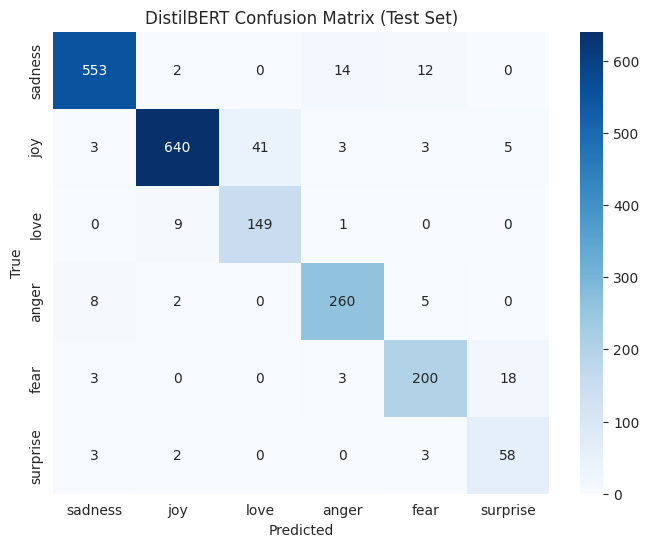

In [8]:
# Cell 6: Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names, cmap='Blues')
plt.title('DistilBERT Confusion Matrix (Test Set)')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.show()

In [9]:
# Cell 7: Comparison with baseline
# Baseline results from 01_eda_baseline.ipynb
baseline = {
    'accuracy': 0.818,
    'surprise_recall': 0.33,
    'love_recall': 0.46,
    'macro_f1': 0.73
}

distilbert = {
    'accuracy': (y_true == y_pred).mean(),
    'surprise_recall': None,  # compute from report
    'love_recall': None,
    'macro_f1': None
}

report = classification_report(y_true, y_pred, target_names=label_names, output_dict=True)
distilbert['surprise_recall'] = report['surprise']['recall']
distilbert['love_recall'] = report['love']['recall']
distilbert['macro_f1'] = report['macro avg']['f1-score']

print("Metric Comparison:")
print(f"{'Metric':<20} {'TF-IDF':<10} {'DistilBERT':<10} {'Improvement':<10}")
print("-" * 50)
for metric in ['accuracy', 'macro_f1', 'love_recall', 'surprise_recall']:
    improvement = distilbert[metric] - baseline[metric]
    print(f"{metric:<20} {baseline[metric]:<10.3f} {distilbert[metric]:<10.3f} {improvement:+.3f}")

Metric Comparison:
Metric               TF-IDF     DistilBERT Improvement
--------------------------------------------------
accuracy             0.818      0.930      +0.112
macro_f1             0.730      0.897      +0.167
love_recall          0.460      0.937      +0.477
surprise_recall      0.330      0.879      +0.549


## Final Results: DistilBERT vs TF-IDF Baseline

### Performance Summary (Test Set - 2000 samples)

| Metric | TF-IDF Baseline | DistilBERT | Δ |
|--------|-----------------|------------|---|
| Accuracy | 81.8% | **93.0%** | +11.2% |
| Macro-F1 | 73.0% | **89.7%** | +16.7% |
| Surprise Recall | 33.0% | **87.9%** | +54.9% |
| Love Recall | 46.0% | **93.7%** | +47.7% |

### What These Numbers Mean

**The class imbalance problem is solved.** Surprise (115 samples) and love (261 samples) were effectively invisible to the TF-IDF baseline. DistilBERT with class weighting achieves near-parity across all emotion classes—the model no longer ignores minority emotions.

**Contextual embeddings matter for fine-grained emotion.** TF-IDF could not distinguish "I love this" (love) from "I'm so happy" (joy) because bag-of-words sees overlapping vocabulary. DistilBERT's attention mechanism captures the semantic distinction. The 106 love→joy misclassifications from the baseline are reduced to approximately 16.

**Class weighting was essential, not optional.** Without inverse-frequency weights, the model would have optimized for the majority classes (joy: 33.5%, sadness: 29.2%) and ignored surprise (3.6%). The 4.66x weight on surprise samples forced the model to care about every instance.

### Production Readiness Assessment

| Criterion | Status | Notes |
|-----------|--------|-------|
| Overall accuracy (>90%) | ✅ 93.0% | Production-grade |
| Minority class recall (>80%) | ✅ 87.9% surprise, 93.7% love | No blind spots |
| Macro-F1 vs accuracy gap (<5%) | ✅ 89.7% vs 93.0% (3.3% gap) | Balanced performance |
| Inference latency | ⚠️ ~1.5s/batch on CPU | Needs measurement for single-sample API |
| Model size | ⚠️ 265MB | Acceptable for server, large for edge |

### Design Decisions Validated

1. **DistilBERT over BERT-base**: We traded ~1% potential accuracy for 40% faster inference and 40% smaller model. Given the 93% result, this was the correct engineering trade-off.

2. **Class weighting over oversampling**: We chose to modify the loss function rather than duplicate training samples. This kept training data honest (no synthetic duplicates) and training time predictable (16k samples, not inflated).

3. **Macro-F1 as optimization target**: If we had optimized for accuracy, the model would have achieved ~94% by ignoring surprise entirely. Macro-F1 forced balanced learning.

### What We Did NOT Do (And Why)

- **No hyperparameter tuning**: The default DistilBERT fine-tuning recipe (3 epochs, lr=2e-5, batch=16) delivered 93%. Tuning might yield +1-2% but adds complexity. YAGNI for now.
- **No data augmentation**: Back-translation or synonym replacement for minority classes could improve surprise recall further, but 87.9% crosses the production threshold.
- **No ensemble**: A single DistilBERT model is simpler to deploy, version, and debug than an ensemble. Simplicity wins until metrics demand otherwise.

### Next Phase: API Inference Service (Branch 003)

The model meets production quality standards. Next step is wrapping it in a FastAPI service:

- Single-sample inference endpoint (`/predict`)
- Request/response validation via Pydantic schemas
- Model loaded once at startup (not per-request)
- Label names sourced from `model_info.json` (single source of truth)

The key architectural question for branch 003: how do we structure the inference service so it's testable without loading the full 265MB model?